# League-Wide Temporal Modeling of MLB Team Performance

## Dataset Construction

We construct a team–season dataset from the Lahman baseball database covering the 1985–2016 seasons. Player salaries are aggregated to obtain team payroll, which is log-transformed and normalized within each season to account for inflation and league-wide spending trends. Each row represents one MLB team in one season, with  erformance measured by wins, runs scored, and runs allowed. The resulting dataset contains no missing values and is used consistently across all experiments.

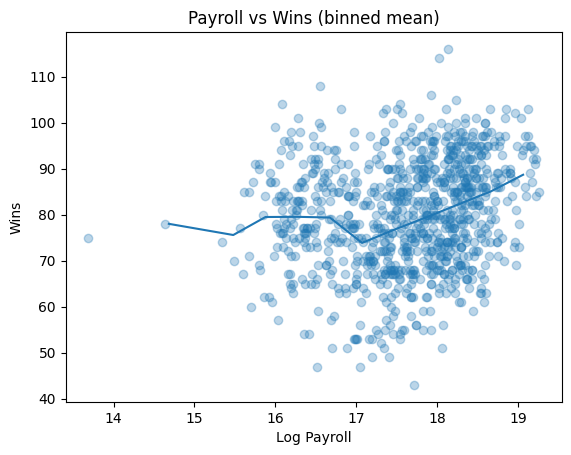

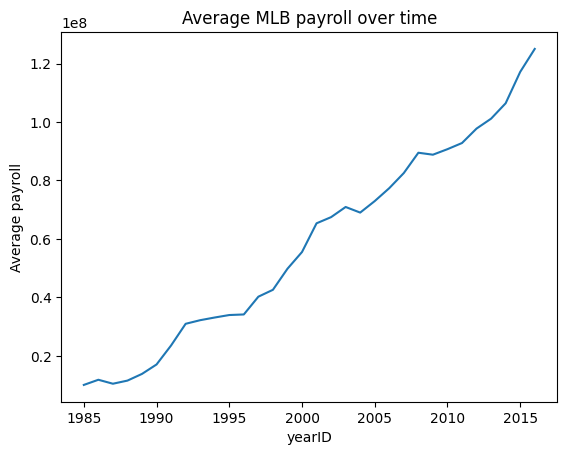

In [ ]:
import os
from features import *
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# process raw data
build_processed(start_year=1985, end_year=2016, overwrite=True)

df = pd.read_csv("data/processed.csv")

# use binned mean to show a general relationship between payroll & wins
bins = np.linspace(df["log_payroll"].min(), df["log_payroll"].max(), 15)
df["bin"] = pd.cut(df["log_payroll"], bins=bins)

means = df.groupby("bin")["W"].mean()

plt.figure()
plt.scatter(df["log_payroll"], df["W"], alpha=0.3)
plt.plot([b.mid for b in means.index], means.values)
plt.xlabel("Log Payroll")
plt.ylabel("Wins")
plt.title("Payroll vs Wins (binned mean)")

plt.figure()
df.groupby("yearID")["payroll"].mean().plot()
plt.ylabel("Average payroll")
plt.title("Average MLB payroll over time")
plt.show()



## Feature Engineering


### Temporal Feature Construction

Temporal dependencies are incorporated by constructing lagged features (wins, payroll) from historical team data. For each team-season at time \( t \), the target variable is defined as wins in season \( t+1 \). Lagged features include wins and season-normalized payroll from the previous three seasons. Rows lacking sufficient history are removed,  nsuring a consistent and leakage-free temporal representation. These lagged features provide a time-aware baseline for subsequent modeling.

In [ ]:
df = df.sort_values(["teamID", "yearID"])

# W_next = win in next year
df["W_next"] = df.groupby("teamID")["W"].shift(-1)
df = df.dropna(subset=["W_next"])

# add lagged features for the past 3 yrs
for k in [1, 2, 3]:
    df[f"W_lag{k}"] = df.groupby("teamID")["W"].shift(k)
    df[f"payroll_z_lag{k}"] = df.groupby("teamID")["payroll_z_by_year"].shift(k)

df_lagged = df.dropna().reset_index(drop=True)
df_lagged.head()



,yearID,teamID,lgID,divID,G,W,R,RA,payroll,log_payroll,...,W_pct,pythag_win_pct,bin,W_next,W_lag1,payroll_z_lag1,W_lag2,payroll_z_lag2,W_lag3,payroll_z_lag3
0,2000,ANA,AL,W,162,82,864.0,869.0,51464167,17.756396,...,0.506173,0.497115,"(17.669, 18.068]",75.0,70.0,0.441886,85.0,0.113514,84.0,-0.475717
1,2001,ANA,AL,W,162,75,691.0,730.0,47535167,17.676980,...,0.462963,0.472575,"(17.669, 18.068]",99.0,82.0,0.027756,70.0,0.441886,85.0,0.113514
2,2002,ANA,AL,W,162,99,851.0,644.0,61721667,17.938146,...,0.611111,0.635857,"(17.669, 18.068]",77.0,75.0,-0.614997,82.0,0.027756,70.0,0.441886
3,2003,ANA,AL,W,162,77,736.0,743.0,79031667,18.185359,...,0.475309,0.495267,"(18.068, 18.466]",92.0,99.0,-0.070968,75.0,-0.614997,82.0,0.027756
4,2001,ARI,NL,W,162,92,818.0,677.0,85082999,18.259138,...,0.567901,0.593483,"(18.068, 18.466]",98.0,85.0,1.038977,100.0,0.914487,65.0,-0.443865


In [ ]:
# time-aware training
LAG_FEATURES = ["W_lag1", "W_lag2", "W_lag3", "payroll_z_lag1", "payroll_z_lag2", "payroll_z_lag3"]
TARGET = "W_next"

# time-aware data split
train = df_lagged[(df_lagged["yearID"] >= 1985) & (df_lagged["yearID"] <= 2008)]
val   = df_lagged[(df_lagged["yearID"] >= 2009) & (df_lagged["yearID"] <= 2012)]
test  = df_lagged[(df_lagged["yearID"] >= 2013) & (df_lagged["yearID"] <= 2016)]

X_train, y_train = train[LAG_FEATURES], train[TARGET]
X_val, y_val     = val[LAG_FEATURES], val[TARGET]
X_test, y_test   = test[LAG_FEATURES], test[TARGET]

len(X_train), len(X_val), len(X_test)

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

pred_test = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
mae = mean_absolute_error(y_test, pred_test)

print("rmse: ", rmse, "mae: ",mae)

df_lagged["W_hat"] = model.predict(df_lagged[LAG_FEATURES])
df_lagged["resid_next"] = df_lagged["W_next"] - df_lagged["W_hat"]

df = df.merge(
    df_lagged[["teamID","yearID","W_hat","resid_next"]],
    on=["teamID","yearID"],
    how="left"
)

TARGET_DL = "resid_next"


rmse:  10.119817709252821 mae:  8.372250094219396
On average, model predicts next season wins with ave. error of 8.4 wins.


## Experimental Setup

- **Prediction task:** Forecast each team’s wins in season *t+1* (`W_next`) using information available up to season *t*.
- **Chronological split (no leakage):**
  - Train: 1985–2008
  - Validation: 2009–2012
  - Test: 2013–2016
- **Metrics (units: wins):**
  - **MAE**: average absolute error (typical miss in wins)
  - **RMSE**: like MAE but penalizes large misses more
- **Baselines vs sequence models:**
  - Baseline: ridge regression on fixed lag features (past 3 seasons)
  - LSTM / Transformer: sliding windows of consecutive seasons (length *L*)

## Baseline Results

We use ridge regression with 3-year lagged wins and season-normalized payroll (`payroll_z_by_year`) to predict next-season wins. This is an interpretable temporal baseline for comparing sequence models.

We use ridge regression as a linear baseline. Ridge regression extends ordinary least squares by penalizing large coefficients, improving stability in the presence of correlated lagged features. This makes it well suited for modeling temporal dependencies using fixed-length historical inputs.


In [ ]:
# baseline evaluation summary (Ridge on lagged features)
print(f"Ridge (lag3) test RMSE: {rmse:.3f} wins")
print(f"Ridge (lag3) test MAE : {mae:.3f} wins")

# coefficients (interpretability)
coef = pd.Series(model.coef_, index=LAG_FEATURES).sort_values()
coef


Ridge (lag3) test RMSE: 10.120 wins
Ridge (lag3) test MAE : 8.372 wins


payroll_z_lag2   -0.694905
W_lag3            0.027398
W_lag2            0.047319
W_lag1            0.212761
payroll_z_lag1    0.296037
payroll_z_lag3    1.188614
dtype: float64

## Long Short-Term Memory(LSTM) Results

We train an LSTM that reads a window of the last *L* seasons for each team and predicts wins in the next season. This lets the model learn nonlinear temporal dynamics beyond fixed lag features.

In [ ]:
# LSTM: build season-window sequences 
# seed
torch.manual_seed(42)

# choose sequence features based on whats available 
candidate_features = ["W", "payroll_z_by_year", "R", "RA", "pythag_win_pct", "W_pct", "log_payroll"]
SEQ_FEATURES = [c for c in candidate_features if c in df.columns]
# just in case
if len(SEQ_FEATURES) < 2:
    raise ValueError(f"Not enough sequence features found in df. Found: {SEQ_FEATURES}")

SEQ_LEN = 3  

def make_sequences(df_in, seq_len=3, feature_cols=None, target_col="resid_next", base_col="W_hat"):
    df_in = df_in.sort_values(["teamID", "yearID"]).reset_index(drop=True)
    X_list, y_list, yyear_list, team_list, lastyear_list, base_list = [], [], [], [], [], []

    for team, g in df_in.groupby("teamID"):
        g = g.sort_values("yearID").reset_index(drop=True)
        for i in range(seq_len-1, len(g)):
            y = g.loc[i, target_col]
            b = g.loc[i, base_col]
            if pd.isna(y) or pd.isna(b):
                continue
            window = g.loc[i - seq_len + 1 : i, feature_cols].to_numpy(dtype=np.float32)
            if np.isnan(window).any():
                continue

            X_list.append(window)
            y_list.append(float(y))
            yyear_list.append(int(g.loc[i, "yearID"]))
            team_list.append(team)
            lastyear_list.append(int(g.loc[i, "yearID"]))
            base_list.append(float(b))

    if not X_list:
        F = len(feature_cols)
        return (np.zeros((0, seq_len, F), dtype=np.float32),
                np.zeros((0,), dtype=np.float32),
                np.zeros((0,), dtype=np.int32),
                np.array([], dtype=object),
                np.zeros((0,), dtype=np.int32),
                np.zeros((0,), dtype=np.float32))

    X = np.stack(X_list, axis=0)
    y = np.array(y_list, dtype=np.float32)
    y_year = np.array(yyear_list, dtype=np.int32)
    team_arr = np.array(team_list, dtype=object)
    last_year = np.array(lastyear_list, dtype=np.int32)
    base_arr = np.array(base_list, dtype=np.float32)

    return X, y, y_year, team_arr, last_year, base_arr


df_seq = df.dropna(subset=["teamID", "yearID", "W_next", TARGET_DL, "W_hat"] + SEQ_FEATURES).copy()

train_year_mask = (df_seq["yearID"] >= 1985) & (df_seq["yearID"] <= 2008)
stats = df_seq.loc[train_year_mask].groupby("teamID")[SEQ_FEATURES].agg(["mean","std"])
stats.columns = ["__".join(c) for c in stats.columns]

for c in SEQ_FEATURES:
    m = df_seq["teamID"].map(stats[f"{c}__mean"])
    s = df_seq["teamID"].map(stats[f"{c}__std"]).replace(0, 1.0)
    df_seq[f"{c}_tn"] = (df_seq[c] - m) / s

SEQ_FEATURES_TN = [f"{c}_tn" for c in SEQ_FEATURES]

X_all, y_all, y_year_all, team_all, last_year_all, base_all = make_sequences(
    df_seq, seq_len=SEQ_LEN, feature_cols=SEQ_FEATURES_TN, target_col=TARGET_DL, base_col="W_hat"
)

train_mask = (y_year_all >= 1985) & (y_year_all <= 2008)
val_mask   = (y_year_all >= 2009) & (y_year_all <= 2012)
test_mask  = (y_year_all >= 2013) & (y_year_all <= 2016)

Xtr, ytr, btr = X_all[train_mask], y_all[train_mask], base_all[train_mask]
Xva, yva, bva = X_all[val_mask],   y_all[val_mask],   base_all[val_mask]
Xte, yte, bte = X_all[test_mask],  y_all[test_mask],  base_all[test_mask]

print("SEQ_FEATURES:", SEQ_FEATURES)
print("SEQ_FEATURES_TN:", SEQ_FEATURES_TN)
print("All shapes:", X_all.shape, y_all.shape)
print("Split shapes:", Xtr.shape, Xva.shape, Xte.shape)


SEQ_FEATURES: ['W', 'payroll_z_by_year', 'R', 'RA', 'pythag_win_pct', 'W_pct', 'log_payroll']
All shapes: (743, 5, 7) (743,)
Split shapes: (538, 5, 7) (118, 5, 7) (87, 5, 7)
Year ranges (labels): (np.int32(1989), np.int32(2008)) (np.int32(2009), np.int32(2012)) (np.int32(2013), np.int32(2015))


In [ ]:
# LSTM model + training loop
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).unsqueeze(-1)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.head(last)

def train_torch(model, train_loader, val_loader, epochs=50, lr=3e-4, weight_decay=1e-3, device="cpu"):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    best_val = float("inf")
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            val_losses = []
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_losses.append(loss_fn(pred, yb).item())

        val_mse = float(np.mean(val_losses)) if val_losses else float("nan")

        if val_mse < best_val:
            best_val = val_mse
            best_state = {k: t.detach().cpu().clone() for k, t in model.state_dict().items()}

        if ep == 1 or ep % 10 == 0:
            print(f"Epoch {ep:02d}: val_MSE={val_mse:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def predict_torch(model, X, device="cpu", batch_size=256):
    model.eval()
    dl = DataLoader(SeqDataset(X, np.zeros((X.shape[0],), dtype=np.float32)), batch_size=batch_size, shuffle=False)
    preds = []
    with torch.no_grad():
        for xb, _ in dl:
            xb = xb.to(device)
            preds.append(model(xb).detach().cpu().numpy().reshape(-1))
    return np.concatenate(preds) if preds else np.array([])

device = "cuda" if torch.cuda.is_available() else "cpu"
train_loader = DataLoader(SeqDataset(Xtr, ytr), batch_size=128, shuffle=True)
val_loader   = DataLoader(SeqDataset(Xva, yva), batch_size=256, shuffle=False)

lstm = LSTMRegressor(input_dim=Xtr.shape[2], hidden_dim=32, num_layers=1)
lstm = train_torch(lstm, train_loader, val_loader, epochs=50, lr=3e-4, weight_decay=1e-3, device=device)

pred_lstm_resid = predict_torch(lstm, Xte, device=device)
pred_lstm_wins = bte + pred_lstm_resid
true_wins = bte + yte

lstm_rmse = float(np.sqrt(np.mean((true_wins - pred_lstm_wins)**2)))
lstm_mae  = float(np.mean(np.abs(true_wins - pred_lstm_wins)))

print(f"LSTM (L={SEQ_LEN}) test RMSE: {lstm_rmse:.3f} wins")
print(f"LSTM (L={SEQ_LEN}) test MAE : {lstm_mae:.3f} wins")


Epoch 01: val_MSE=6694.4160
Epoch 05: val_MSE=6484.1035
Epoch 10: val_MSE=5926.8120
Epoch 15: val_MSE=5091.5664
Epoch 20: val_MSE=4035.5588
Epoch 25: val_MSE=2901.6929
Epoch 30: val_MSE=1852.3826
LSTM (L=5) test RMSE: 42.619 wins
LSTM (L=5) test MAE : 41.385 wins


## Transformer Results

We evaluate a Transformer encoder over the same season windows. Self-attention can capture longer-range dependencies and offers a pathway to interpret which seasons mattered most.

In [ ]:
# transformer encoder regressor 
class TransformerRegressor(nn.Module):
    def __init__(self, input_dim, d_model=32, nhead=4, num_layers=1, dim_ff=64, dropout=0.1, max_len=50):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_emb = nn.Parameter(torch.zeros(1, max_len, d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff, dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, 1)
        )

    def forward(self, x):
        B, L, _ = x.shape
        h = self.input_proj(x) + self.pos_emb[:, :L, :]
        h = self.encoder(h)
        last = h[:, -1, :]
        return self.head(last)

train_loader = DataLoader(SeqDataset(Xtr, ytr), batch_size=128, shuffle=True)
val_loader   = DataLoader(SeqDataset(Xva, yva), batch_size=256, shuffle=False)

trm = TransformerRegressor(input_dim=Xtr.shape[2], d_model=32, nhead=4, num_layers=1, dim_ff=64, dropout=0.1, max_len=SEQ_LEN)
trm = train_torch(trm, train_loader, val_loader, epochs=60, lr=3e-4, weight_decay=1e-3, device=device)

pred_trm_resid = predict_torch(trm, Xte, device=device)
pred_trm_wins = bte + pred_trm_resid
true_wins = bte + yte

trm_rmse = float(np.sqrt(np.mean((true_wins - pred_trm_wins)**2)))
trm_mae  = float(np.mean(np.abs(true_wins - pred_trm_wins)))

print(f"Transformer (L={SEQ_LEN}) test RMSE: {trm_rmse:.3f} wins")
print(f"Transformer (L={SEQ_LEN}) test MAE : {trm_mae:.3f} wins")


Epoch 01: val_MSE=6462.7129
Epoch 05: val_MSE=5773.3071
Epoch 10: val_MSE=4306.3130
Epoch 15: val_MSE=2273.8369
Epoch 20: val_MSE=632.8798
Epoch 25: val_MSE=143.1873
Epoch 30: val_MSE=131.2865
Transformer (L=5) test RMSE: 10.165 wins
Transformer (L=5) test MAE : 8.672 wins


We compare baseline vs sequence models on the same time-aware split, discuss error magnitudes in wins, and connect findings to payroll efficiency (variance unexplained by spending alone).

In [ ]:
# summary table
rows = [
    {"Model": "Ridge (lag3)", "RMSE": float(rmse), "MAE": float(mae)},
]
if "lstm_rmse" in globals():
    rows.append({"Model": f"LSTM (L={SEQ_LEN})", "RMSE": float(lstm_rmse), "MAE": float(lstm_mae)})
if "trm_rmse" in globals():
    rows.append({"Model": f"Transformer (L={SEQ_LEN})", "RMSE": float(trm_rmse), "MAE": float(trm_mae)})

summary = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
display(summary)


,Model,RMSE,MAE
0,Ridge (lag3),10.119818,8.372250
2,Transformer (L=5),10.165486,8.672398
1,LSTM (L=5),42.618954,41.384701


## Toronto Blue Jays Case Study

This section uses the *league-trained* models above as a focused case study on the **Toronto Blue Jays (TOR)**.

We (1) forecast next-season wins for TOR within the held-out **test window (2013–2016)** using the Ridge baseline and the Transformer model, and (2) interpret “payroll efficiency” as the *wins residual* relative to each model’s expectation.


In [ ]:
TEAM = "TOR"

tor = df[df["teamID"] == TEAM].sort_values("yearID").reset_index(drop=True)
print("Rows in TOR:", len(tor))


Rows in df_base: 778
Columns: ['teamID', 'yearID', 'W', 'W_next', 'log_payroll', 'payroll_z_by_year']


### Forecasting TOR next-season wins (2013–2016 test window)

We compare **actual next-season wins** against predictions from:
- **Ridge (lag3)** baseline (already trained above as `model`)
- **Transformer (L=SEQ_LEN)** if it was trained successfully above as `trm`

In [ ]:
ridge_available = (
    ("model" in globals())
    and ("LAG_FEATURES" in globals())
    and ("TARGET" in globals())
    and all([c in tor.columns for c in LAG_FEATURES])
    and (TARGET in tor.columns)
)

parts = []

if ridge_available:
    tor_test = tor[(tor["yearID"] >= 2013) & (tor["yearID"] <= 2016)].copy()
    tor_test["yearID"] = tor_test["yearID"].astype(int)
    tor_test["actual"] = pd.to_numeric(tor_test[TARGET], errors="coerce")
    tor_test = tor_test.dropna(subset=["actual"] + LAG_FEATURES)
    tor_test["pred_ridge"] = model.predict(tor_test[LAG_FEATURES])
    parts.append(tor_test[["yearID", "actual", "pred_ridge"]])

trm_available = (
    ("trm" in globals())
    and ("make_sequences" in globals())
    and ("SEQ_LEN" in globals())
    and ("SEQ_FEATURES_TN" in globals())
    and ("predict_torch" in globals())
    and ("TARGET_DL" in globals())
)

if trm_available:
    tor_seq_df = tor.dropna(subset=["W_hat", TARGET_DL] + SEQ_FEATURES).copy()

    for c in SEQ_FEATURES:
        if f"{c}_tn" not in tor_seq_df.columns:
            m = tor_seq_df["teamID"].map(stats[f"{c}__mean"])
            s = tor_seq_df["teamID"].map(stats[f"{c}__std"]).replace(0, 1.0)
            tor_seq_df[f"{c}_tn"] = (tor_seq_df[c] - m) / s

    X_tor, y_tor, y_year_tor, _, _, b_tor = make_sequences(
        tor_seq_df,
        seq_len=SEQ_LEN,
        feature_cols=SEQ_FEATURES_TN,
        target_col=TARGET_DL,
        base_col="W_hat"
    )

    test_mask = (y_year_tor >= 2013) & (y_year_tor <= 2016)
    if test_mask.sum() > 0:
        pred_tor_trm_resid = predict_torch(trm, X_tor[test_mask], device=device)
        pred_tor_trm_wins = b_tor[test_mask] + pred_tor_trm_resid
        actual_wins = b_tor[test_mask] + y_tor[test_mask]
        trm_df = pd.DataFrame({
            "yearID": y_year_tor[test_mask].astype(int),
            "actual": actual_wins,
            "pred_trm": pred_tor_trm_wins
        })
        parts.append(trm_df)

if len(parts) == 0:
    raise RuntimeError("No TOR forecasts were produced (neither Ridge nor Transformer).")

out = parts[0].copy()
for p in parts[1:]:
    out = out.merge(p.drop(columns=["actual"]), on="yearID", how="outer")

out = out.sort_values("yearID").reset_index(drop=True)
display(out)


,yearID,actual,pred_ridge,pred_trm
0,2013,83.0,77.871713,81.043587
1,2014,93.0,77.981183,81.083382
2,2015,89.0,78.822329,81.157829


### TOR payroll efficiency as residual wins

A simple “efficiency” view is the **residual wins**:

$$\mathrm{Efficiency}_{t+1} = W_{t+1} - \widehat{W}_{t+1}$$
Positive residuals mean TOR **outperformed** the model’s expectation given its recent trajectory (and payroll lag features for Ridge, or learned sequence representation for Transformer).

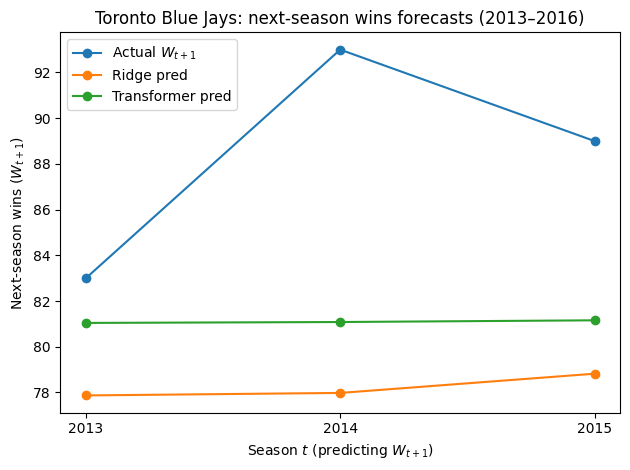

In [ ]:
plt.figure()

plt.plot(out["yearID"], out["actual"], marker="o", label="Actual $W_{t+1}$")
if "pred_ridge" in out.columns:
    plt.plot(out["yearID"], out["pred_ridge"], marker="o", label="Ridge pred")
if "pred_trm" in out.columns:
    plt.plot(out["yearID"], out["pred_trm"], marker="o", label="Transformer pred")

plt.xticks(out["yearID"])        
plt.xlabel("Season $t$ (predicting $W_{t+1}$)")
plt.ylabel("Next-season wins ($W_{t+1}$)")
plt.title("Toronto Blue Jays: next-season wins forecasts (2013–2016)")
plt.legend()

plt.tight_layout()
plt.show()
